In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/matches.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(104, 42)
['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team', 'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue', 'referee', 'home_formation', 'away_formation', 'home_manager', 'away_manager', 'home_captain', 'away_captain', 'home_possession', 'away_possession', 'home_sot', 'away_sot', 'home_total_shots', 'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow', 'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls', 'away_fouls', 'home_corners', 'away_corners', 'home_crosses', 'away_crosses', 'home_interceptions', 'away_interceptions', 'home_offsides', 'away_offsides', 'notes']


,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [2]:
print(df[["home_total_shots", "away_total_shots"]].isna().sum())
print(df["round"].value_counts())

home_total_shots    0
away_total_shots    0
dtype: int64
round
Group stage          72
Round of 32          16
Round of 16           8
Quarter-finals        4
Semi-finals           2
Third-place match     1
Final                 1
Name: count, dtype: int64


In [3]:
# Reshape home rows
home = df[["round", "gameweek", "date", "home_team", "away_team", "home_total_shots"]].copy()
home.columns = ["round", "gameweek", "date", "team", "opponent", "shots"]

# Reshape away rows
away = df[["round", "gameweek", "date", "away_team", "home_team", "away_total_shots"]].copy()
away.columns = ["round", "gameweek", "date", "team", "opponent", "shots"]

# Combine into one long table
team_matches = pd.concat([home, away], ignore_index=True)
print(team_matches.shape)
team_matches.head()

(208, 6)


,round,gameweek,date,team,opponent,shots
0,Group stage,1.0,2026-06-11,Mexico,South Africa,16
1,Group stage,1.0,2026-06-11,Korea Republic,Czechia,15
2,Group stage,1.0,2026-06-12,Canada,Bosnia–Herz,13
3,Group stage,1.0,2026-06-12,United States,Paraguay,16
4,Group stage,1.0,2026-06-13,Qatar,Switzerland,7


In [4]:
knockout_rounds = ["Round of 32", "Round of 16", "Quarter-finals", "Semi-finals", "Third-place match", "Final"]

knockout_shots = team_matches.loc[team_matches["round"].isin(knockout_rounds), "shots"]

print("Population size (knockout team-match rows):", len(knockout_shots))
print(knockout_shots.describe())

Population size (knockout team-match rows): 64
count    64.000000
mean     12.515625
std       5.806379
min       2.000000
25%       7.000000
50%      12.500000
75%      16.250000
max      25.000000
Name: shots, dtype: float64


In [5]:
import numpy as np

np.random.seed(42)
n = 30  # a commonly used sample size threshold for t-distribution approximation
sample_shots = knockout_shots.sample(n=n, random_state=42)

print(f"Population size: {len(knockout_shots)}")
print(f"Sample size: {len(sample_shots)}")
print(sample_shots.describe())

Population size: 64
Sample size: 30
count    30.000000
mean     12.333333
std       5.579107
min       5.000000
25%       8.000000
50%      12.500000
75%      15.750000
max      25.000000
Name: shots, dtype: float64


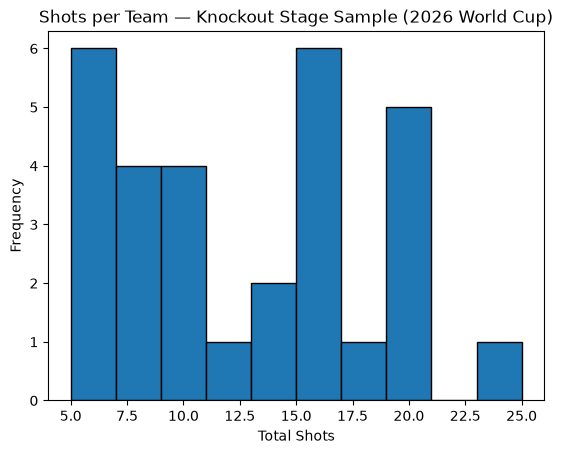

In [6]:
import matplotlib.pyplot as plt

plt.hist(sample_shots, bins=10, edgecolor="black")
plt.title("Shots per Team — Knockout Stage Sample (2026 World Cup)")
plt.xlabel("Total Shots")
plt.ylabel("Frequency")
plt.savefig("../outputs/figures/nishan_shots_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
from scipy import stats

benchmark = 13

mean_shots = sample_shots.mean()
sem_shots = stats.sem(sample_shots)
ci_shots = stats.t.interval(confidence=0.95, df=len(sample_shots)-1, loc=mean_shots, scale=sem_shots)

print(f"Sample mean shots (knockout stage): {mean_shots:.2f}")
print(f"95% CI: ({ci_shots[0]:.2f}, {ci_shots[1]:.2f})")
print(f"Benchmark for comparison: {benchmark}")

Sample mean shots (knockout stage): 12.33
95% CI: (10.25, 14.42)
Benchmark for comparison: 13


In [9]:
# H0: mean shots per team in knockout stage = 13 (benchmark)
# H1: mean shots per team in knockout stage ≠ 13 (benchmark)

t_stat, p_value = stats.ttest_1samp(sample_shots, popmean=benchmark)

print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 — average shots significantly differ from the benchmark.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant difference")
    print("from the benchmark of 13 shots per team.")

t-statistic = -0.654
p-value = 0.51795

Result: Fail to reject H0 — no statistically significant difference
from the benchmark of 13 shots per team.


In [10]:
# Use the full tournament average shots (all rounds) as the benchmark, not an external guess
overall_mean_shots = team_matches["shots"].mean()
print(f"Overall tournament mean shots (all matches, all rounds): {overall_mean_shots:.2f}")

Overall tournament mean shots (all matches, all rounds): 12.39


### Note on benchmark selection
Initially, an external benchmark of 13 shots/match was considered (based on general 
knowledge of recent World Cups), but this lacked a citable source. Instead, the 
tournament's own overall average shots per team (12.39) was used as a data-derived, 
defensible benchmark for the one-sample t-test.

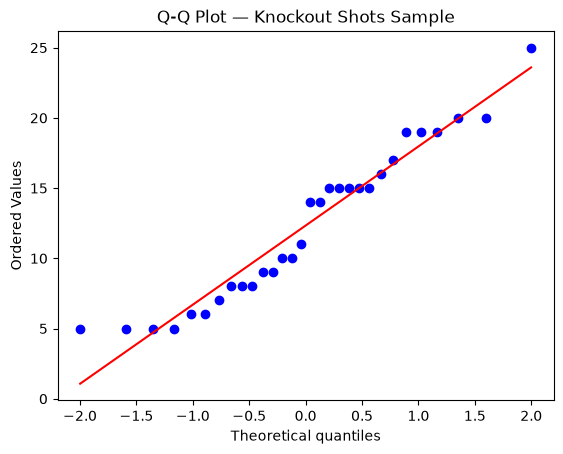

In [12]:
# Check approximate normality of the sample (t-test assumption)
plt.figure()
stats.probplot(sample_shots, dist="norm", plot=plt)
plt.title("Q-Q Plot — Knockout Shots Sample")
plt.savefig("../outputs/figures/nishan_shots_qqplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
benchmark = overall_mean_shots

t_stat, p_value = stats.ttest_1samp(sample_shots, popmean=benchmark)

print(f"Benchmark (overall tournament mean shots): {benchmark:.2f}")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 — knockout-stage shots significantly differ from the tournament-wide average.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant difference")
    print("between knockout-stage shots and the overall tournament average.")

Benchmark (overall tournament mean shots): 12.39
t-statistic = -0.060
p-value = 0.95274

Result: Fail to reject H0 — no statistically significant difference
between knockout-stage shots and the overall tournament average.
